<a href="https://colab.research.google.com/github/httppaulinaar/Probabilidad-y-estad-stica/blob/main/Unidad5/Practicafinal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Unidad 5
##Probabilidad y estadística
##Practica final:Regresión lineal y correlación
###Docente: José Gabriel Rodríguez Rivas
###Alumna: América Paulina Álvarez Rivera

In [6]:
#librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')

In [7]:
#cargar datos
df1 = pd.read_csv("grupo1.csv")
df2 = pd.read_csv("grupo2.csv")
df3 = pd.read_csv("grupo3.csv")

grupos = {1: df1, 2: df2, 3: df3}

In [8]:
for i, df in grupos.items():
    print(f"\n{'='*50}")
    print(f"  GRUPO {i} — Primeras filas")
    print(f"{'='*50}")
    print(df.head())
    print(f"\n  Descripción estadística:")
    print(df.describe())


  GRUPO 1 — Primeras filas
   HorasEstudio  Calificacion
0         20.00         75.94
1         15.60         87.48
2         17.91         79.40
3         20.00         73.37
4         20.00         83.75

  Descripción estadística:
       HorasEstudio  Calificacion
count     50.000000      50.00000
mean      14.352000      83.78820
std        4.219174       7.83389
min        3.790000      68.46000
25%       12.032500      78.03500
50%       14.600000      84.49000
75%       17.715000      88.09000
max       20.000000     100.00000

  GRUPO 2 — Primeras filas
   HorasEstudio  Calificacion
0          3.79          40.0
1          6.08          26.1
2          7.17          29.0
3          7.54          31.9
4          8.18          34.8

  Descripción estadística:
       HorasEstudio  Calificacion
count     50.000000     50.000000
mean      14.352000     75.912000
std        4.219174     20.668922
min        3.790000     26.100000
25%       12.032500     63.500000
50%       14.60000

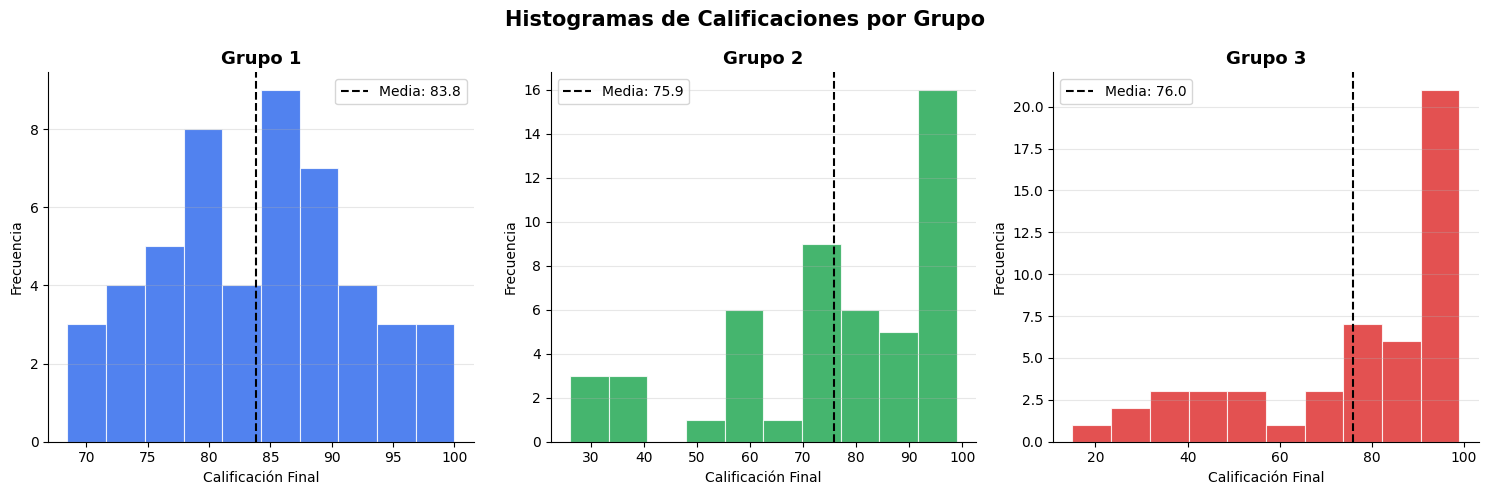


✓ histogramas.png guardado


In [9]:
#histograma de calificaciones
colores = ['#2563EB', '#16A34A', '#DC2626']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Histogramas de Calificaciones por Grupo', fontsize=15, fontweight='bold')

for ax, (i, df), color in zip(axes, grupos.items(), colores):
    ax.hist(df['Calificacion'], bins=10, color=color, alpha=0.8,
            edgecolor='white', linewidth=0.8)
    ax.axvline(df['Calificacion'].mean(), color='black', linestyle='--',
               linewidth=1.5, label=f"Media: {df['Calificacion'].mean():.1f}")
    ax.set_title(f'Grupo {i}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Calificación Final')
    ax.set_ylabel('Frecuencia')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("histogramas.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ histogramas.png guardado")

In [10]:
resultados = {}

for i, df in grupos.items():
    X = df['HorasEstudio'].values
    y = df['Calificacion'].values

    # --- scikit-learn ---
    reg = LinearRegression().fit(X.reshape(-1, 1), y)
    pendiente  = reg.coef_[0]
    intercepto = reg.intercept_
    y_pred     = reg.predict(X.reshape(-1, 1))
    r2         = reg.score(X.reshape(-1, 1), y)

    # --- Correlación de Pearson ---
    r, p_pearson = stats.pearsonr(X, y)

    # --- statsmodels (p-valores, F-stat) ---
    X_sm = sm.add_constant(X)
    modelo = sm.OLS(y, X_sm).fit()
    p_pendiente = modelo.pvalues[1]
    f_stat      = modelo.fvalue
    f_pvalue    = modelo.f_pvalue

    resultados[i] = {
        'X': X, 'y': y, 'y_pred': y_pred,
        'pendiente': pendiente, 'intercepto': intercepto,
        'r': r, 'r2': r2,
        'p_pearson': p_pearson, 'p_pendiente': p_pendiente,
        'f_stat': f_stat, 'f_pvalue': f_pvalue
    }

In [11]:
    signo = '+' if intercepto >= 0 else '-'
    print(f"\n{'='*50}")
    print(f"  GRUPO {i} — Resultados del Modelo")
    print(f"{'='*50}")
    print(f"  Ecuación de regresión : y = {pendiente:.4f}x {signo} {abs(intercepto):.4f}")
    print(f"  Pendiente (β₁)        : {pendiente:.4f}")
    print(f"  Intercepto (β₀)       : {intercepto:.4f}")
    print(f"  Correlación Pearson r : {r:.4f}")
    print(f"  Coeficiente R²        : {r2:.4f}")
    print(f"  p-valor (pendiente)   : {p_pendiente:.4e}")
    print(f"  Estadístico F         : {f_stat:.4f}")
    print(f"  p-valor (F)           : {f_pvalue:.4e}")
    significativo = "SÍ ✓" if f_pvalue < 0.05 else "NO ✗"
    print(f"  Significativo α=0.05  : {significativo}")



  GRUPO 3 — Resultados del Modelo
  Ecuación de regresión : y = 5.2857x + 0.1081
  Pendiente (β₁)        : 5.2857
  Intercepto (β₀)       : 0.1081
  Correlación Pearson r : 0.9422
  Coeficiente R²        : 0.8878
  p-valor (pendiente)   : 1.9342e-24
  Estadístico F         : 379.6907
  p-valor (F)           : 1.9342e-24
  Significativo α=0.05  : SÍ ✓


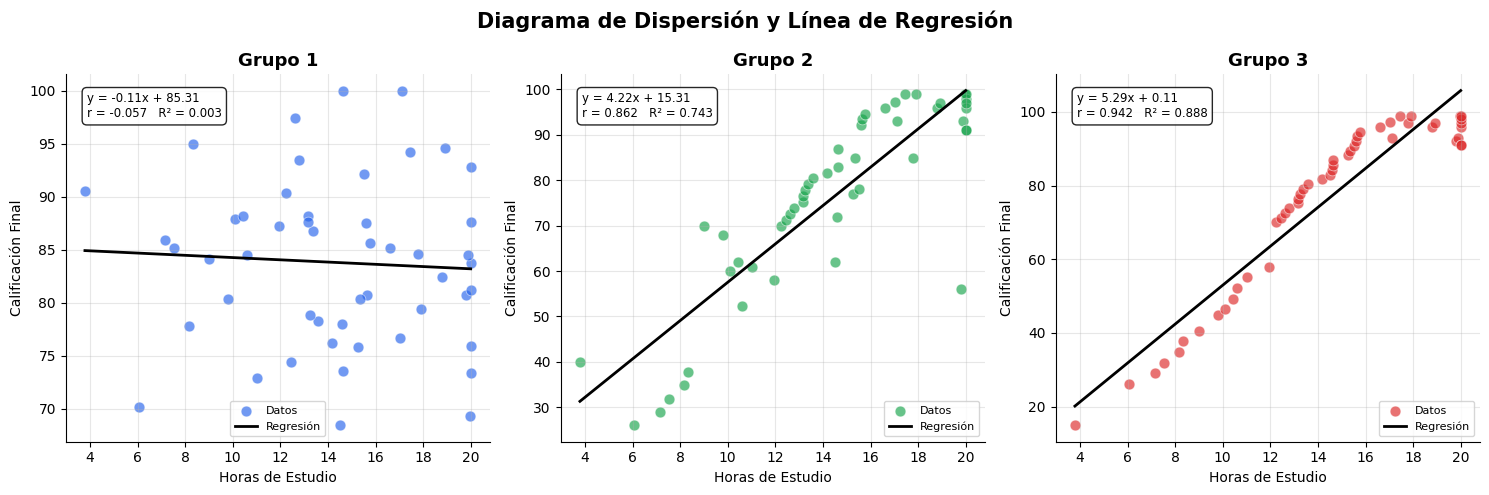


✓ regresion.png guardado


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Diagrama de Dispersión y Línea de Regresión', fontsize=15, fontweight='bold')

for ax, (i, res), color in zip(axes, resultados.items(), colores):
    X, y = res['X'], res['y']
    pendiente  = res['pendiente']
    intercepto = res['intercepto']
    r, r2      = res['r'], res['r2']

    # Scatter
    ax.scatter(X, y, color=color, alpha=0.65,
               edgecolors='white', s=60, linewidths=0.5, label='Datos')

    # Línea de regresión
    x_linea = np.linspace(X.min(), X.max(), 100)
    ax.plot(x_linea, pendiente * x_linea + intercepto,
            'k-', linewidth=2, label='Regresión')

    ax.set_title(f'Grupo {i}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Horas de Estudio')
    ax.set_ylabel('Calificación Final')

    # Anotación con ecuación y métricas
    signo = '+' if intercepto >= 0 else '-'
    ecuacion = f'y = {pendiente:.2f}x {signo} {abs(intercepto):.2f}'
    texto = f'{ecuacion}\nr = {r:.3f}   R² = {r2:.3f}'
    ax.text(0.05, 0.95, texto, transform=ax.transAxes, fontsize=8.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    ax.legend(fontsize=8)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("regresion.png", dpi=150, bbox_inches='tight')
plt.show()
print("\n✓ regresion.png guardado")

In [13]:
print(f"\n{'='*70}")
print(f"  TABLA RESUMEN COMPARATIVA")
print(f"{'='*70}")
print(f"{'Grupo':<8} {'Pendiente':>10} {'Intercepto':>12} {'r':>8} {'R²':>8} {'p-valor(F)':>14} {'Sig.':>6}")
print(f"{'-'*70}")
for i, res in resultados.items():
    sig = "Sí ✓" if res['f_pvalue'] < 0.05 else "No ✗"
    print(f"Grupo {i}   {res['pendiente']:>10.4f} {res['intercepto']:>12.4f} "
          f"{res['r']:>8.4f} {res['r2']:>8.4f} {res['f_pvalue']:>14.4e} {sig:>6}")
print(f"{'='*70}")


  TABLA RESUMEN COMPARATIVA
Grupo     Pendiente   Intercepto        r       R²     p-valor(F)   Sig.
----------------------------------------------------------------------
Grupo 1      -0.1061      85.3107  -0.0571   0.0033     6.9351e-01   No ✗
Grupo 2       4.2227      15.3075   0.8620   0.7430     9.0777e-16   Sí ✓
Grupo 3       5.2857       0.1081   0.9422   0.8878     1.9342e-24   Sí ✓


¿Cuál es la interpretación del coeficiente de regresión (pendiente β₁)?

La pendiente representa cuánto cambia la calificación por cada hora extra de estudio.

En el Grupo 1 (β₁ = −0.11), por cada hora adicional de estudio la calificación disminuye 0.11 puntos. Sin embargo, esto no tiene una interpretación causal real, ya que el resultado no es estadísticamente significativo (p = 0.69). Esto indica que prácticamente no existe una relación lineal entre las horas de estudio y las calificaciones en este grupo.

En el Grupo 2 (β₁ = 4.22), cada hora adicional de estudio se relaciona con un aumento aproximado de 4.22 puntos en la calificación. Esto muestra una relación positiva y bastante fuerte.

En el Grupo 3 (β₁ = 5.29), cada hora extra de estudio aumenta alrededor de 5.29 puntos en la calificación. Este es el grupo donde la relación entre ambas variables es más fuerte y consistente.

¿Cómo se interpreta el coeficiente de correlación de Pearson?

El coeficiente de correlación de Pearson indica qué tan fuerte y en qué dirección se relacionan las horas de estudio con las calificaciones.

En el Grupo 1 (r = −0.057), la correlación es prácticamente nula y ligeramente negativa. Esto significa que no existe una relación lineal clara entre estudiar más horas y obtener mejores calificaciones.

En el Grupo 2 (r = 0.862), la correlación es positiva y fuerte. Esto quiere decir que, en general, mientras más horas estudian los alumnos, mejores son sus calificaciones.

En el Grupo 3 (r = 0.942), la correlación es positiva muy fuerte, casi perfecta. Aquí las horas de estudio explican casi completamente el comportamiento de las calificaciones.

¿El modelo de regresión lineal es estadísticamente significativo?

Tomando como referencia un nivel de significancia de α = 0.05, el Grupo 1 no es estadísticamente significativo porque su p-valor es de 0.6935, mucho mayor que 0.05. Por lo tanto, no se puede afirmar que exista una relación lineal entre las variables.

En el Grupo 2, el modelo sí es significativo, ya que el p-valor es 9.08×10⁻¹⁶, mucho menor que 0.05. Esto demuestra que existe una relación lineal clara entre las horas de estudio y las calificaciones.

En el Grupo 3 también existe significancia estadística, porque el p-valor es 1.93×10⁻²⁴. De los tres grupos, este es el resultado más fuerte y confiable.

¿Qué tan confiable es el modelo para predecir calificaciones?

El coeficiente R² muestra qué porcentaje de la variación de las calificaciones puede ser explicado por las horas de estudio.

En el Grupo 1 (R² = 0.003), el modelo no es confiable, ya que explica menos del 1% de la variación en las calificaciones. Esto significa que las horas de estudio prácticamente no ayudan a predecir el resultado.

En el Grupo 2 (R² = 0.743), el modelo es moderadamente confiable, porque las horas de estudio explican el 74% de la variación en las calificaciones. Aun así, existe un porcentaje que depende de otros factores.

En el Grupo 3 (R² = 0.888), el modelo es muy confiable, ya que explica el 89% de la variación observada. Esto indica que las predicciones realizadas con este modelo son bastante precisas dentro del rango analizado.

CONCLUSIÓN GENERAL
En conclusión, el análisis de regresión lineal y correlación permitió observar cómo las horas de estudio pueden influir en las calificaciones dependiendo del comportamiento de los datos en cada grupo. En el Grupo 1 prácticamente no existe relación entre las variables, ya que tanto la correlación como el modelo de regresión mostraron resultados muy bajos y sin significancia estadística. En cambio, en los Grupos 2 y 3 sí se encontró una relación positiva fuerte, donde al aumentar las horas de estudio también aumentan las calificaciones.

Además, el valor de R² mostró qué tan confiables son los modelos para realizar predicciones. El Grupo 3 fue el más preciso y consistente, mientras que el Grupo 2 también presentó buenos resultados, aunque con un poco más de variación. Con esto se puede concluir que la regresión lineal y el coeficiente de correlación son herramientas útiles para analizar relaciones entre variables y para estimar resultados futuros cuando los datos presentan una tendencia clara.